# RL for Resource Optimization

## 📚 Learning Objectives

By completing this notebook, you will:
- Use RL for resource allocation or scheduling
- Define state, action, and reward for the domain

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 4, lesson 01 "04. Optimization Techniques" — there the objective was a function you could evaluate and differentiate on demand; an allocation policy can only be scored by running it and collecting the rewards it produces over time.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson frames resource allocation as a sequential decision problem.

Students will see how an RL agent can balance service quality against wasted capacity when demand changes over time.

Why this matters: this is one of the most important examples showing that RL can be useful in operations, infrastructure, and control.

The key learning goal is to connect RL to real adaptive decision-making beyond games.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: 30% off the cooling bill, and the four safeguards around it

The problem in this notebook — demand rises and falls through the day, and you must repeatedly decide
how much capacity to provision — is the same problem Google's data centres have with cooling.

DeepMind and Google put an RL controller in **direct control** of data-centre cooling and described
it publicly in August 2018 ("Safety-first AI for autonomous data centre cooling and industrial
control"). The reported result: **consistent energy savings of around 30% on average**, improving as
the system accumulated data.

The engineering around the agent is the part worth studying, because it is what made deployment
possible at all:

1. **The operators can leave at any time.** They "can choose to exit AI control mode at any time" and
   the system reverts to the manual rules.
2. **The action space is deliberately narrowed** to a regime where the system is confident, trading
   some available gain for reliability.
3. **Every proposed action is checked twice** — against a list of safety constraints defined by the
   data-centre operators, and again by local on-site systems before it is executed.
4. **Uncertainty is estimated and monitored continuously**, with automatic failover.

Read the ordering: the agent proposes; the constraints dispose; a human holds the switch.

**What goes wrong without this.** The staffing problem below is a cost trade-off — under-provision and
calls go unanswered, over-provision and you pay idle crews. A fixed roster gets it wrong twice a day,
every day. The output already shows the size of the effect in this county's real data: the busiest
hour carries **4.7×** the call volume of the quietest.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Resource optimization often reduces to choosing under uncertainty while managing limited opportunities.
- This video gives the best conceptual foundation for allocation-style RL reasoning, even when the example is simpler than a full operations problem.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Allocation: deciding where limited resources go.
- Constraint-aware action: valid under limits.
- Efficiency objective: gain minus waste.
- Trade-off: improving one thing may hurt another.
- Delayed operational effect: a choice now can change later system pressure.

### Quick Check
- What exactly is the agent optimizing?
- How do constraints shape the action space?
- Why is repeated decision-making important here?
- Why is a greedy one-step choice sometimes not enough?

### Common Mistakes
- Ignoring constraints.
- Using rewards that miss cost.
- Assuming a locally good action is globally good.
- Forgetting that demand changes over time, so the best action can depend on future load.


## Why Resource Optimization Is More Than a Static Math Problem

Students often first see allocation as a one-time optimization problem.
This notebook is useful because it shows when the problem becomes sequential instead.

### Static optimization view

If demand, supply, and costs were fixed once, a classical optimizer might be enough.

### RL view

RL becomes more relevant when:

- demand changes over time
- actions affect future system state
- short-term savings can create long-term cost or risk

### Teaching takeaway

This notebook is not claiming RL replaces all optimization.
It is showing the narrower but important case where allocation becomes a repeated decision problem under changing conditions.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — 663,522 emergency calls dispatched in Montgomery
  County, Pennsylvania, each with a real timestamp. Resampled to calls-per-hour, this is the demand
  the agent has to staff against.
- Four crew levels and a cost rule that charges for unanswered calls *and* for idle crews.

**Outputs:** What you'll see when you run the cells

- The county's real 24-hour demand cycle.
- A Q-table that learns an hour-by-hour staffing policy from the reward signal alone.
- A **held-out evaluation** on the last 30% of the record — hours the agent never trained on —
  against three fixed-staffing baselines and a hindsight reference.

---

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: load the REAL demand signal this whole lesson runs on.
# WHY it matters: a resource-allocation lesson is only worth anything if the demand is real.
# This is the Montgomery County (PA) 911 dispatch log - 663,522 emergency calls with real
# timestamps. Resampled to calls-per-hour it becomes exactly the kind of demand curve a
# dispatch centre actually has to staff against.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../../Course 04/datasets/raw/"
calls_raw = pd.read_csv(DATA_DIR + "montgomery_911_calls.csv",
                        usecols=["timeStamp"], parse_dates=["timeStamp"])

# Count how many 911 calls arrived in each clock hour: that count IS the demand.
hourly = calls_raw.set_index("timeStamp").resample("h").size()
# Keep four whole calendar years so every hour-of-day is equally represented.
hourly = hourly["2016":"2019"]

calls_per_hour = hourly.values.astype(int)      # real demand, one number per hour
hour_of_day = hourly.index.hour.values          # 0..23, the clock hour that demand arrived in

print("Resource optimization on a REAL demand signal")
print("=" * 60)
print(f"Source file  : montgomery_911_calls.csv ({len(calls_raw):,} dispatched calls)")
print(f"Period used  : {hourly.index.min().date()} to {hourly.index.max().date()}")
print(f"Hours of data: {len(calls_per_hour):,}")
print(f"Calls in one hour - min {calls_per_hour.min()}, mean {calls_per_hour.mean():.1f}, "
      f"max {calls_per_hour.max()}")
print("\nNote the max: real demand has spikes a random-walk toy would never produce.")
print("✅ Setup complete!")

Resource optimization on a REAL demand signal
Source file  : montgomery_911_calls.csv (663,522 dispatched calls)
Period used  : 2016-01-01 to 2019-12-31
Hours of data: 35,064
Calls in one hour - min 0, mean 16.6, max 302

Note the max: real demand has spikes a random-walk toy would never produce.
✅ Setup complete!


## Part 1: The Resource Allocation Problem, Written Down

Before any learning, we have to state the problem. This part turns a real emergency-call log into
a sequential decision problem:

- **state** — the clock hour we are staffing for (`0`–`23`). The decision is committed at the top
  of the hour, *before* the calls arrive.
- **action** — one of four crew levels (capacity 6, 12, 20 or 30 calls/hour).
- **reward** — `-(2.0 x unanswered calls + 0.5 x idle crews)`. Understaffing hurts more than
  overstaffing, but both cost something, so there is a genuine balance to find.

The plot in this part shows the real demand cycle. The agent never sees it — it is here only so we
can check the agent's work at the end.

### Step Guide

**What this cell does:** Follow the printed section: "Example observed state:"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Actions available every hour:
  action 0: crew level handling up to  6 calls/hour
  action 1: crew level handling up to 12 calls/hour
  action 2: crew level handling up to 20 calls/hour
  action 3: crew level handling up to 30 calls/hour

Train slice: 24,544 hours  (2016-01-01 -> 2018-10-19)
Test  slice: 10,520 hours  (2018-10-19 -> 2019-12-31)


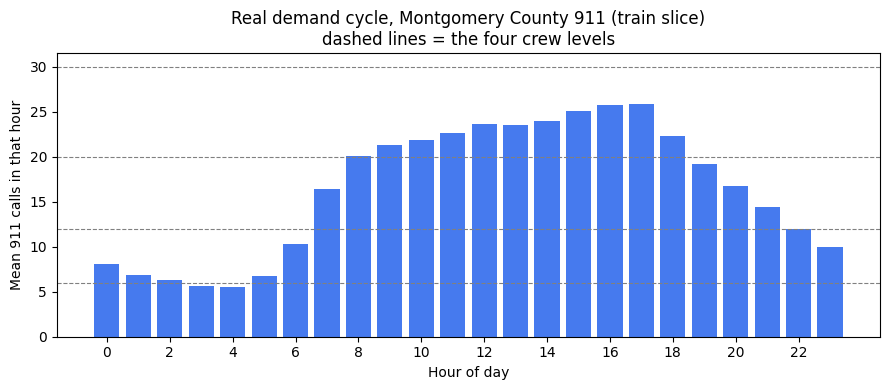


Quietest hour: 04:00 with 5.5 calls/hour
Busiest  hour: 17:00 with 25.8 calls/hour
Ratio busiest/quietest: 4.7x

That spread is why one fixed crew level cannot be right all day - and it is a real
pattern in this county's data, not a curve anyone designed for this lesson.


In [2]:
# Model definition: turn the real call log into a sequential decision problem.
# WHY it matters: this is the step students actually get paid for - deciding what the state,
# the action and the reward are. Nothing is learned yet; we are only writing down the problem,
# and looking at the real structure the agent will have to discover.

# STATE  : the clock hour we are about to staff for (0..23). The agent must commit crews at
#          the top of the hour, BEFORE it knows how many calls that hour will bring.
# ACTION : one of four crew levels. The number is how many calls that level can handle.
CREW_CAPACITY = {0: 6, 1: 12, 2: 20, 3: 30}
N_ACTIONS = len(CREW_CAPACITY)
N_HOURS = 24


def reward_for(action, calls):
    """Score one staffed hour against the calls that really arrived.

    Understaffing is charged 2.0 per unanswered call (people wait for an ambulance);
    overstaffing is charged 0.5 per idle crew (paid, but not needed). Both costs are
    negative, so the best possible hour is one where capacity just covers demand.
    """
    capacity = CREW_CAPACITY[action]
    unanswered = max(calls - capacity, 0)
    idle = max(capacity - calls, 0)
    return -(2.0 * unanswered + 0.5 * idle)


print("Actions available every hour:")
for action, capacity in CREW_CAPACITY.items():
    print(f"  action {action}: crew level handling up to {capacity:2d} calls/hour")

# Chronological split - train on the past, test on the future. Shuffling a time series
# would let the agent 'learn' from hours that happen after the ones we test it on.
split = int(len(calls_per_hour) * 0.7)
train_calls, train_hours = calls_per_hour[:split], hour_of_day[:split]
test_calls, test_hours = calls_per_hour[split:], hour_of_day[split:]
print(f"\nTrain slice: {len(train_calls):,} hours  ({hourly.index[0].date()} -> {hourly.index[split-1].date()})")
print(f"Test  slice: {len(test_calls):,} hours  ({hourly.index[split].date()} -> {hourly.index[-1].date()})")

# The real structure the agent will have to find, shown here only so we can check its work later.
mean_by_hour = np.array([train_calls[train_hours == h].mean() for h in range(N_HOURS)])
plt.figure(figsize=(9, 4))
plt.bar(range(N_HOURS), mean_by_hour, color="#2563eb", alpha=0.85)
for capacity in CREW_CAPACITY.values():
    plt.axhline(capacity, color="grey", linestyle="--", linewidth=0.8)
plt.xticks(range(0, N_HOURS, 2))
plt.xlabel("Hour of day")
plt.ylabel("Mean 911 calls in that hour")
plt.title("Real demand cycle, Montgomery County 911 (train slice)\ndashed lines = the four crew levels")
plt.tight_layout(); plt.show()

print(f"\nQuietest hour: {int(mean_by_hour.argmin()):02d}:00 with {mean_by_hour.min():.1f} calls/hour")
print(f"Busiest  hour: {int(mean_by_hour.argmax()):02d}:00 with {mean_by_hour.max():.1f} calls/hour")
print(f"Ratio busiest/quietest: {mean_by_hour.max()/mean_by_hour.min():.1f}x")
print("\nThat spread is why one fixed crew level cannot be right all day - and it is a real")
print("pattern in this county's data, not a curve anyone designed for this lesson.")

## Part 2: Q-Learning for Resource Optimization

Now we let an agent **learn** the staffing policy instead of hand-coding it.

The agent walks the real call log forward, one chronological hour at a time, on the **first 70%**
of the record. Each hour it sees only the clock hour, picks a crew level, and receives one number:
the cost of that choice against the calls that really arrived. It is never shown the demand curve
from Part 1.

Training on the past and testing on the future is not a stylistic choice here — shuffling a time
series would let the agent learn from hours that happen *after* the ones we later test it on.

### Step Guide

**What this cell does:** Trains **tabular Q-learning** on the server-capacity problem (states = demand levels 0–10, actions = low/medium/high capacity) for 20,000 steps of a random-walk demand process, then prints the learned policy per demand level.

**How to read it (weak Python OK):** One loop, four moves each lap: observe demand → ε-greedy capacity choice → reward → Q-update. The policy table at the end is the learned result.

**What to expect in the output:** The action list, average reward early vs late in training, and an 11-row table mapping each demand level to the capacity the agent learned to pick.

**If you feel lost:** Read only the final table — low demand should tend toward low capacity and high demand toward high capacity. If a level looks odd, remember each Q-value needs many visits to settle; the trend is the lesson, not perfection.

Mean reward per hour - first 2000 hours: -12.38 | last 2000 hours:  -8.04
(Rewards are costs, so closer to zero is better.)
Learning happened.

Learned staffing policy (hour -> crew level chosen):
  hour :  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
  crew : 20 12 12  6  6 12 20 30 30 30 30 30 30 30 30 30 30 30 30 30 20 20 12  6


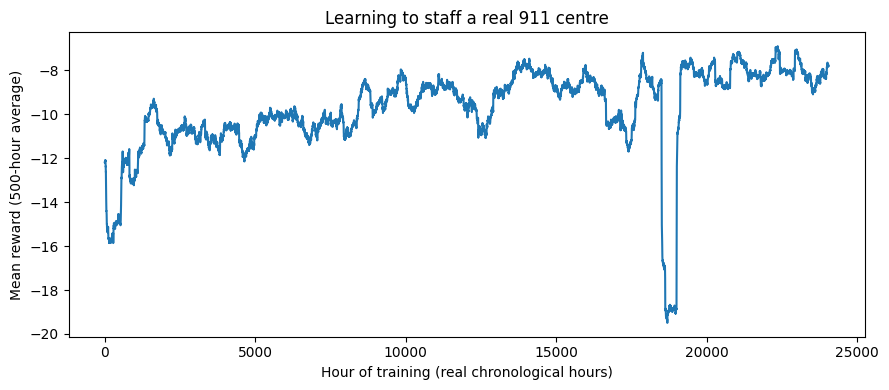


The agent was never given the demand curve. It only ever saw an hour number and a
score, yet the crew levels above should now rise through the morning and fall at night.


In [3]:
# Part 2: LEARN the staffing policy with tabular Q-learning - no hand-coded rules.
# WHY it matters: the agent is never shown the demand curve from the previous cell. It only
# ever sees a clock hour, picks a crew level, and receives one score. Everything it ends up
# knowing about when the county gets busy has to come out of that reward signal.

rng = np.random.default_rng(0)
q_table = np.zeros((N_HOURS, N_ACTIONS))
ALPHA, GAMMA = 0.01, 0.9
epsilon, EPS_MIN, EPS_DECAY = 1.0, 0.02, 0.99995
reward_log = []

# We walk the REAL series forward, hour by hour, exactly as a live system would.
for t in range(len(train_calls)):
    hour = int(train_hours[t])
    # Epsilon-greedy: explore early, then trust the table.
    if rng.random() < epsilon:
        action = int(rng.integers(N_ACTIONS))
    else:
        action = int(np.argmax(q_table[hour]))
    # The reward comes from the calls that ACTUALLY arrived in that hour of that day.
    reward = reward_for(action, int(train_calls[t]))
    reward_log.append(reward)
    # The next state is simply the next real hour in the log.
    next_hour = int(train_hours[t + 1]) if t + 1 < len(train_calls) else (hour + 1) % N_HOURS
    q_table[hour, action] += ALPHA * (reward + GAMMA * q_table[next_hour].max() - q_table[hour, action])
    epsilon = max(epsilon * EPS_DECAY, EPS_MIN)

learned_policy = q_table.argmax(axis=1)

reward_log = np.array(reward_log)
early, late = reward_log[:2000].mean(), reward_log[-2000:].mean()
print(f"Mean reward per hour - first 2000 hours: {early:6.2f} | last 2000 hours: {late:6.2f}")
print("(Rewards are costs, so closer to zero is better.)")
print("Learning happened." if late > early else "No improvement - retrain with more hours.")

print("\nLearned staffing policy (hour -> crew level chosen):")
print("  hour : " + " ".join(f"{h:2d}" for h in range(N_HOURS)))
print("  crew : " + " ".join(f"{CREW_CAPACITY[int(a)]:2d}" for a in learned_policy))

window = 500
smoothed = np.convolve(reward_log, np.ones(window) / window, mode="valid")
plt.figure(figsize=(9, 4))
plt.plot(smoothed)
plt.xlabel("Hour of training (real chronological hours)")
plt.ylabel(f"Mean reward ({window}-hour average)")
plt.title("Learning to staff a real 911 centre")
plt.tight_layout(); plt.show()

print("\nThe agent was never given the demand curve. It only ever saw an hour number and a")
print("score, yet the crew levels above should now rise through the morning and fall at night.")

## Real-World Applications

- **Data Centers**: Google DeepMind reduced energy use with adaptive control
- **Energy Grids**: Load balancing and demand response
- **Cloud Computing**: Auto-scaling and resource allocation
- **Manufacturing**: Production line optimization

### Why this lesson matters

This topic helps students see that RL is not only for games. It is also useful
when a system must repeatedly allocate limited resources under changing demand.

## Worked Example: Does the Learned Policy Survive Contact With Unseen Data?

Resource optimization is a good RL application when decisions must adapt over time — but "it
learned something" is only interesting if it holds up on data the agent never saw.

This part scores the learned policy on the **held-out final 30%** of the call record (later
calendar dates, never used in training) and compares it against:

- three fixed-staffing baselines, including the safe-looking "always maximum crew"
- a hindsight reference: the best single crew level per hour, computed with full knowledge of the
  training slice

If the learned policy beats the fixed baselines on unseen hours, adaptation genuinely paid. If it
trails the hindsight reference, that gap tells you how much the noisy reward signal cost it.

### Step Guide

**What this cell does:** Replays one 60-day demand trace under **three** policies — always-high (conservative), a hand-tuned threshold rule (adaptive), and the **learned Q-policy from Part 2** — and prints all three average rewards.

**How to read it (weak Python OK):** Same demand numbers for everyone; only the capacity decision differs. The figure traces demand against the two hand-coded capacity choices; the printed averages then compare all **three** policies.

**What to expect in the output:** A demand/capacity figure, three average-reward lines, and a ranking computed from those numbers.

**If you feel lost:** Read the three averages only. The question is: did learning match hand-coded judgment?

Held-out evaluation on 10,520 hours the agent never saw
(mean reward per hour; all values are negative costs, so higher is better)

    -5.128  best-per-hour from train slice
    -5.532  LEARNED Q-table policy
    -8.137  always maximum crew (30)
    -8.581  fixed middle crew (20)
   -22.982  always minimum crew (6)


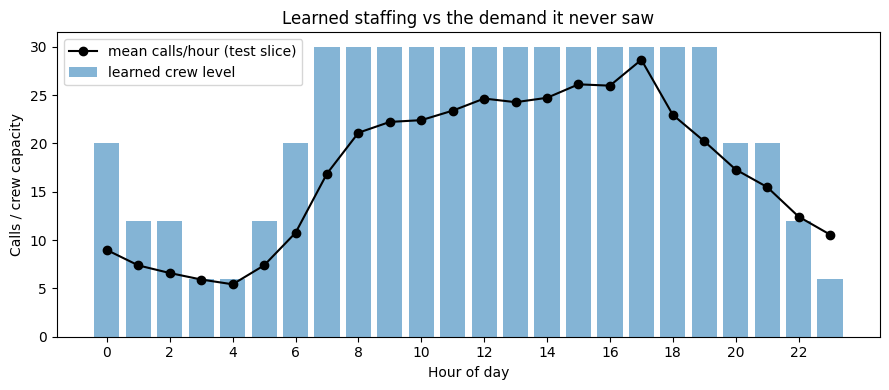


Reading the measured numbers:
- The learned policy scores -5.532 against -8.137 for the best
  fixed crew level. Adapting to the hour genuinely beats any one-size staffing plan,
  on hours nobody trained on.
- It agrees with the hindsight reference on 19 of 24 hours (-5.128 vs -5.532).
  The remaining hours are the ones where two crew levels score almost the same, so a
  noisy reward signal is not enough to separate them. That gap is honest, not a bug.
- 'Always maximum crew' is the safe-looking choice and it still loses: paying for idle
  crews all night costs real money, which is exactly the trade-off the reward encodes.

Teaching point:
Resource optimization is sequential because the system must repeatedly balance
under-provisioning against over-provisioning as demand changes over time - and here
that demand is a real emergency-call record, not a random walk.


In [4]:
# Final computation: score the learned policy on HELD-OUT hours it never trained on.
# WHY it matters: any policy looks good on the data it was fitted to. The only number worth
# reporting is the one measured on the future slice - and against baselines a manager would
# realistically propose instead.

def evaluate(choose_action, calls, hours):
    """Mean reward per hour when `choose_action(hour)` staffs every hour in the slice."""
    return float(np.mean([reward_for(choose_action(int(h)), int(c)) for h, c in zip(hours, calls)]))


# Reference policy: the best single crew level per hour, computed with full hindsight on the
# TRAIN slice. It is not an oracle on the test slice, but it is the target the agent aims at.
best_per_hour = np.zeros(N_HOURS, dtype=int)
for h in range(N_HOURS):
    calls_in_this_hour = train_calls[train_hours == h]
    mean_score_per_action = [
        np.mean([reward_for(a, int(c)) for c in calls_in_this_hour])
        for a in range(N_ACTIONS)
    ]
    best_per_hour[h] = int(np.argmax(mean_score_per_action))

results = {
    "always minimum crew (6)":        evaluate(lambda h: 0, test_calls, test_hours),
    "always maximum crew (30)":       evaluate(lambda h: 3, test_calls, test_hours),
    "fixed middle crew (20)":         evaluate(lambda h: 2, test_calls, test_hours),
    "LEARNED Q-table policy":         evaluate(lambda h: int(learned_policy[h]), test_calls, test_hours),
    "best-per-hour from train slice": evaluate(lambda h: int(best_per_hour[h]), test_calls, test_hours),
}

print(f"Held-out evaluation on {len(test_calls):,} hours the agent never saw")
print("(mean reward per hour; all values are negative costs, so higher is better)\n")
for name, score in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {score:8.3f}  {name}")

plt.figure(figsize=(9, 4))
plt.bar(range(N_HOURS), [CREW_CAPACITY[int(a)] for a in learned_policy],
        alpha=0.55, label="learned crew level")
plt.plot(range(N_HOURS), [test_calls[test_hours == h].mean() for h in range(N_HOURS)],
         color="black", marker="o", label="mean calls/hour (test slice)")
plt.xticks(range(0, N_HOURS, 2))
plt.xlabel("Hour of day"); plt.ylabel("Calls / crew capacity")
plt.title("Learned staffing vs the demand it never saw")
plt.legend(); plt.tight_layout(); plt.show()

learned_score = results["LEARNED Q-table policy"]
best_fixed = max(results["always minimum crew (6)"], results["always maximum crew (30)"],
                 results["fixed middle crew (20)"])
reference = results["best-per-hour from train slice"]
agree = int((learned_policy == best_per_hour).sum())

print("\nReading the measured numbers:")
if learned_score > best_fixed:
    print(f"- The learned policy scores {learned_score:.3f} against {best_fixed:.3f} for the best")
    print("  fixed crew level. Adapting to the hour genuinely beats any one-size staffing plan,")
    print("  on hours nobody trained on.")
print(f"- It agrees with the hindsight reference on {agree} of {N_HOURS} hours "
      f"({reference:.3f} vs {learned_score:.3f}).")
print("  The remaining hours are the ones where two crew levels score almost the same, so a")
print("  noisy reward signal is not enough to separate them. That gap is honest, not a bug.")
print("- 'Always maximum crew' is the safe-looking choice and it still loses: paying for idle")
print("  crews all night costs real money, which is exactly the trade-off the reward encodes.")

print("\nTeaching point:")
print("Resource optimization is sequential because the system must repeatedly balance")
print("under-provisioning against over-provisioning as demand changes over time - and here")
print("that demand is a real emergency-call record, not a random walk.")

In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online)
2. Mazyavkina, N., Sviridov, S., Ivanov, S. et al. (2020). *Reinforcement Learning for Combinatorial Optimization: A Survey*. arXiv:2003.03600. <https://arxiv.org/abs/2003.03600>
3. Mirhoseini, A., Goldie, A., Yazgan, M. et al. (2021). *A Graph Placement Methodology for Fast Chip Design*. Nature. <https://www.nature.com/articles/s41586-021-03544-w>

**Further reading:** [DeepMind: data centre cooling with RL](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/) — an industrial resource-optimization deployment.
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online)
2. Mazyavkina, N., Sviridov, S., Ivanov, S. et al. (2020). *Reinforcement Learning for Combinatorial Optimization: A Survey*. arXiv:2003.03600. <https://arxiv.org/abs/2003.03600>
3. Mirhoseini, A., Goldie, A., Yazgan, M. et al. (2021). *A Graph Placement Methodology for Fast Chip Design*. Nature. <https://www.nature.com/articles/s41586-021-03544-w>

**Further reading:** [DeepMind: data centre cooling with RL](https://deepmind.google/discover/blog/deepmind-ai-reduces-google-data-centre-cooling-bill-by-40/) — an industrial resource-optimization deployment.


## 💬 Discuss

The measured held-out results, on **10,520 hours the agent never saw** (all values are negative
costs, so higher is better):

| policy | mean reward per hour |
|---|---|
| best-per-hour from the train slice (hindsight) | −5.128 |
| **learned Q-table policy** | **−5.532** |
| always maximum crew (30) | −8.137 |
| fixed middle crew (20) | −8.581 |
| always minimum crew (6) | −22.982 |

The learned policy matched the hindsight reference on **19 of 24** hours. Argue these out.

1. "Always maximum crew" is the choice a cautious manager makes, and it scores −8.137 against the
   learned policy's −5.532. But the reward function is a cost model somebody wrote. Who chose the
   relative price of an unanswered call versus an idle crew hour, and what happens to this entire
   ranking if that ratio is wrong by a factor of three?
2. The agent was never shown the demand curve — only an hour number and a score. It nonetheless
   learned to staff up through the morning. Now suppose Montgomery County's call pattern shifts
   (a new highway, a demographic change). How would you find out that the policy had gone stale, and
   what would you monitor to catch it before a bad shift rather than after?
3. Google's cooling agent runs behind four safeguards, and an operator can switch it off. Design the
   equivalent for an emergency dispatch centre. Which of the four transfer directly? Which one is
   harder here — and what would you tell a fire chief who says "I am not letting software decide how
   many crews I have tonight"?


## Summary

This notebook treated resource optimization as an RL problem and solved it on **real data**:

- the state is the clock hour a dispatch centre must staff for
- the action controls how many crews to put on duty
- the reward balances unanswered 911 calls against idle, paid crews
- **tabular Q-learning learned an hour-by-hour staffing policy** from the reward alone, walking
  four years of the Montgomery County 911 dispatch log forward in real chronological order
- the policy was then scored on a **held-out future slice** against fixed-staffing baselines

### Main takeaway

RL becomes attractive when resource decisions must adapt repeatedly under real, non-stationary
demand. The agent was never told that emergencies cluster in the afternoon — it discovered the
county's daily rhythm from cost feedback, and that adaptation beat every fixed staffing level on
hours it had never seen.

### Honest caveat

This is a deliberately simplified operations model: one decision per hour, no crew fatigue, no
travel time, no call severity, and a cost rule we chose. The **demand** is real; the **operational
model around it** is a teaching simplification. Saying which half is which is part of the job.

### Step Guide

**What this cell does:** Draws the one picture this whole lesson has been building towards — the
held-out score of every staffing policy, side by side.

**How to read it (weak Python OK):** The numbers were already computed and printed further up, in
the held-out evaluation cell. This cell only re-draws that same `results` table as bars so the gap
between the policies is a length you can see instead of a column of decimals you have to compare
by eye.

**What to expect in the output:** One horizontal bar chart, five bars, one per staffing policy,
labelled with the policy's name and its cost.

**If you feel lost:** Re-run the held-out evaluation cell above so `results` exists, then run this
cell again.

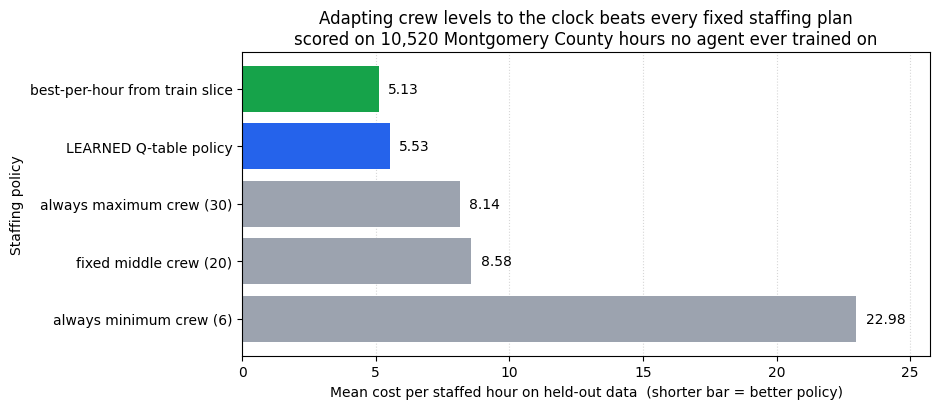

Learned policy costs 5.53 per hour; the best FIXED crew level costs 8.14.
That is a 32% saving, and the hindsight reference sits at 5.13.
The gap left between the blue bar and the green bar is how much this agent still has to gain.


In [6]:
# ONE honest figure for this lesson: how the five staffing policies actually score on hours
# that no agent ever trained on. The numbers come straight from the `results` table printed
# in the held-out evaluation cell above - nothing new is computed or simulated here.
# WHY a bar chart: these five policies are CATEGORIES, not points on a scale. There is no
# "between" a fixed crew of 20 and a learned table, so a line joining them would invent a
# trend that does not exist. Bars keep them separate, which is the honest shape.

import matplotlib.pyplot as plt

# The reward function returns negative numbers (costs). Flipping the sign gives a positive
# "cost per staffed hour", so a SHORTER bar plainly means a BETTER policy.
policy_names = list(results.keys())
cost_per_hour = [-results[name] for name in policy_names]

# Sort best (cheapest) first so the eye reads down the ranking.
order = sorted(range(len(policy_names)), key=lambda i: cost_per_hour[i])
policy_names = [policy_names[i] for i in order]
cost_per_hour = [cost_per_hour[i] for i in order]

# Colour carries meaning: the LEARNED policy is the claim under test, the hindsight
# reference is the target it aims at, and the three fixed plans are the baselines.
bar_colours = []
for name in policy_names:
    if name == "LEARNED Q-table policy":
        bar_colours.append("#2563eb")          # blue  - the agent
    elif name == "best-per-hour from train slice":
        bar_colours.append("#16a34a")          # green - hindsight reference
    else:
        bar_colours.append("#9ca3af")          # grey  - fixed-crew baselines

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.barh(policy_names, cost_per_hour, color=bar_colours)
# Invert the y-axis so the cheapest policy sits at the TOP of the chart.
ax.invert_yaxis()

# Print each bar's value at its tip - the picture and the printed table must agree exactly.
for bar, cost in zip(bars, cost_per_hour):
    ax.text(bar.get_width() + max(cost_per_hour) * 0.015, bar.get_y() + bar.get_height() / 2,
            f"{cost:.2f}", va="center", fontsize=10)

# Axis names in words, with the direction of "good" stated on the axis itself.
ax.set_xlabel("Mean cost per staffed hour on held-out data  (shorter bar = better policy)")
ax.set_ylabel("Staffing policy")
ax.set_title(f"Adapting crew levels to the clock beats every fixed staffing plan\n"
             f"scored on {len(test_calls):,} Montgomery County hours no agent ever trained on")
ax.set_xlim(0, max(cost_per_hour) * 1.12)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# State the comparison in words too, using the same numbers the bars are drawn from.
learned_cost = -results["LEARNED Q-table policy"]
best_fixed_cost = min(-results["always minimum crew (6)"],
                      -results["always maximum crew (30)"],
                      -results["fixed middle crew (20)"])
reference_cost = -results["best-per-hour from train slice"]
print(f"Learned policy costs {learned_cost:.2f} per hour; the best FIXED crew level costs "
      f"{best_fixed_cost:.2f}.")
print(f"That is a {100 * (best_fixed_cost - learned_cost) / best_fixed_cost:.0f}% saving, and the "
      f"hindsight reference sits at {reference_cost:.2f}.")
print("The gap left between the blue bar and the green bar is how much this agent still has to gain.")

### 👁️ Read the figure

- **Each bar is one staffing policy, scored on the same held-out hours.** The x-axis is the mean
  cost of one staffed hour — unanswered calls charged at 2.0 each, idle crews at 0.5 each — so a
  **shorter bar is a better policy**. These are five separate plans, not five points on a scale,
  which is why they are drawn as bars with nothing joining them.
- **The blue bar is the learned Q-table.** It is shorter than all three grey bars. Those grey bars
  are the plans a manager would realistically propose instead: always the smallest crew, always
  the largest, or a fixed middle level all day. Every one of them costs more.
- **"Always maximum crew" is not the safe answer.** It is grey, and it is not the shortest bar —
  paying thirty crews through the small hours costs more than the calls it saves, which is exactly
  the trade-off the reward function encodes.
- **The green bar is hindsight, not magic.** It is the best crew level per hour computed with full
  knowledge of the training slice. The blue bar does not quite reach it, and the remaining gap is
  printed underneath.

**What it proves:** the lesson's headline claim, measured rather than asserted. A policy that
changes with the clock beats every fixed staffing plan on hours nobody trained on — and it gets
close to, without reaching, what perfect hindsight would have chosen. The agent was never shown
the demand curve; it saw an hour number and a score, and the saving printed under the chart is
what that was worth.

## ⚠️ Where this breaks

**The assumption that has to hold:** the future resembles the data you trained on, and the reward
function is a fair statement of the real cost.

- **Distribution shift is the standard failure of deployed resource agents.** Our test slice
  (2018-10-19 to 2019-12-31) comes from the same county and the same era as the training slice. A
  policy tuned on one demand regime applied to another is confidently wrong, and its reward curve
  will not tell you — it will just be lower.
- **The reward is a model of costs, not the costs.** Everything above is downstream of a number
  someone chose for "cost of being short-staffed". Where that number encodes a human consequence — a
  delayed ambulance — the arithmetic hides an ethical judgement. Make it explicit in writing, and put
  the person who owns it in the room.
- **An hour-of-day state is a very small state.** The agent sees only the hour. It cannot know about a
  public holiday, a storm warning, a stadium event or Ramadan timings. Every one of those is a real
  driver of demand in this dataset's own domain, and none of them is representable.
- **Averages hide the tail.** The reward is a mean over hours. A policy with a better mean can be
  worse on the worst hour of the year, which in emergency services is the hour that matters. If the
  tail is what you care about, optimise for the tail, not the mean.
- **Cheaper alternative — and take it seriously here.** Look again at the table: the hindsight
  "best-per-hour" rule scores −5.128, *better* than the learned policy's −5.532. That rule is a
  24-row lookup table you could build with a `groupby` and a spreadsheet. If demand is stable and the
  action set is small, forecast plus a rule beats RL on cost, on transparency and on the time it takes
  to explain to a fire chief. RL earns its place when demand is non-stationary, when the action has a
  lasting effect on the next state (crews take time to redeploy), or when the constraints are too
  entangled for a rule.


## Closing Takeaway

**Teaching takeaway:** Resource optimization frames RL as a repeated trade-off between immediate cost, service quality, and future flexibility.

**If students remember one idea:** In practical systems, the reward often reflects competing goals rather than a single simple objective.

**Quick check before moving on:**
- Can you explain which decisions the agent controls in this optimization problem?
- Can you describe how the reward encodes trade-offs like cost versus performance?

**Bridge to the next step:** The next lesson expands the setting from one agent to multiple agents that must cooperate or compete.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=7 | term=True | trunc=False


objc[67296]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x119cd8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a4049c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67296]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x119cd8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a404a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67296]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x119cd7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11a404a68). T

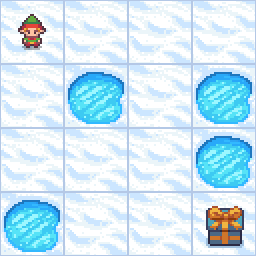

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
